In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [41]:
import pandas as pd
file_path = r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Home Assignment\Home Assingment 2\data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [42]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
print("Number of Samples:", df.shape[0])
print("Number of Features/Columns:", df.shape[1])

Number of Samples: 569
Number of Features/Columns: 32


In [44]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [45]:
print("Columns:")
print(df.columns.tolist())

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [46]:
print("\nTarget Column:")
print(df["diagnosis"].value_counts())


Target Column:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [47]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Series([], dtype: int64)

Total Missing Values: 0


In [48]:
print(df["diagnosis"].value_counts())

print("\nClass Distribution (%):")
print(
    df["diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [49]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [50]:
df = df.drop("id", axis=1)

In [51]:
print(df.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [52]:
df = df.drop(
    columns=["id", "Unnamed: 32"],
    errors="ignore"
)

print("Dataset Shape After Cleaning:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())

Dataset Shape After Cleaning: (569, 31)
Total Missing Values: 0


In [53]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


X → 30 input features (569, 30)
y → diagnosis (B / M) (569,)

In [54]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))

Original Classes: ['B' 'M']
Encoded classes: [0 1]


In [56]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Classes:", label_encoder.classes_)
print("Encoded Classes:", np.unique(y_encoded))
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

Original Classes: ['B' 'M']
Encoded Classes: [0 1]
{'B': np.int64(0), 'M': np.int64(1)}


### Target Encoding

The diagnosis labels were encoded numerically: Benign (B) = 0 and Malignant (M) = 1.

In [57]:
print("Encoded Class Distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

Encoded Class Distribution:
0    357
1    212
Name: count, dtype: int64


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (455, 30)
Testing Set: (114, 30)


In [59]:
stratify=y_encoded

In [60]:
print("Training Class Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution:")
print(pd.Series(y_test).value_counts())

Training Class Distribution:
0    285
1    170
Name: count, dtype: int64

Testing Class Distribution:
0    72
1    42
Name: count, dtype: int64


In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (455, 30)
Scaled Testing Shape: (114, 30)


### Feature Scaling

StandardScaler was fitted on the training data and applied to both training and testing features to place all numerical features on a comparable scale while avoiding data leakage.

In [63]:
print("===== FINAL PREPROCESSING CHECK =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("\nTraining Classes:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting Classes:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nMissing Values in Original Cleaned Data:",
      df.isnull().sum().sum())

===== FINAL PREPROCESSING CHECK =====
X_train: (455, 30)
X_test : (114, 30)
X_train_scaled: (455, 30)
X_test_scaled : (114, 30)

Training Classes:
0    285
1    170
Name: count, dtype: int64

Testing Classes:
0    72
1    42
Name: count, dtype: int64

Missing Values in Original Cleaned Data: 0


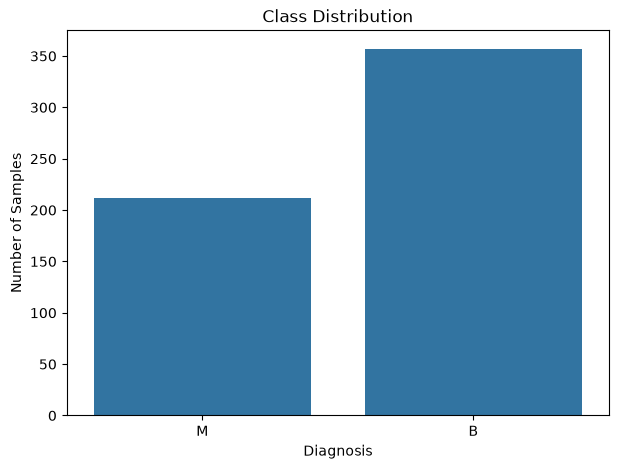

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

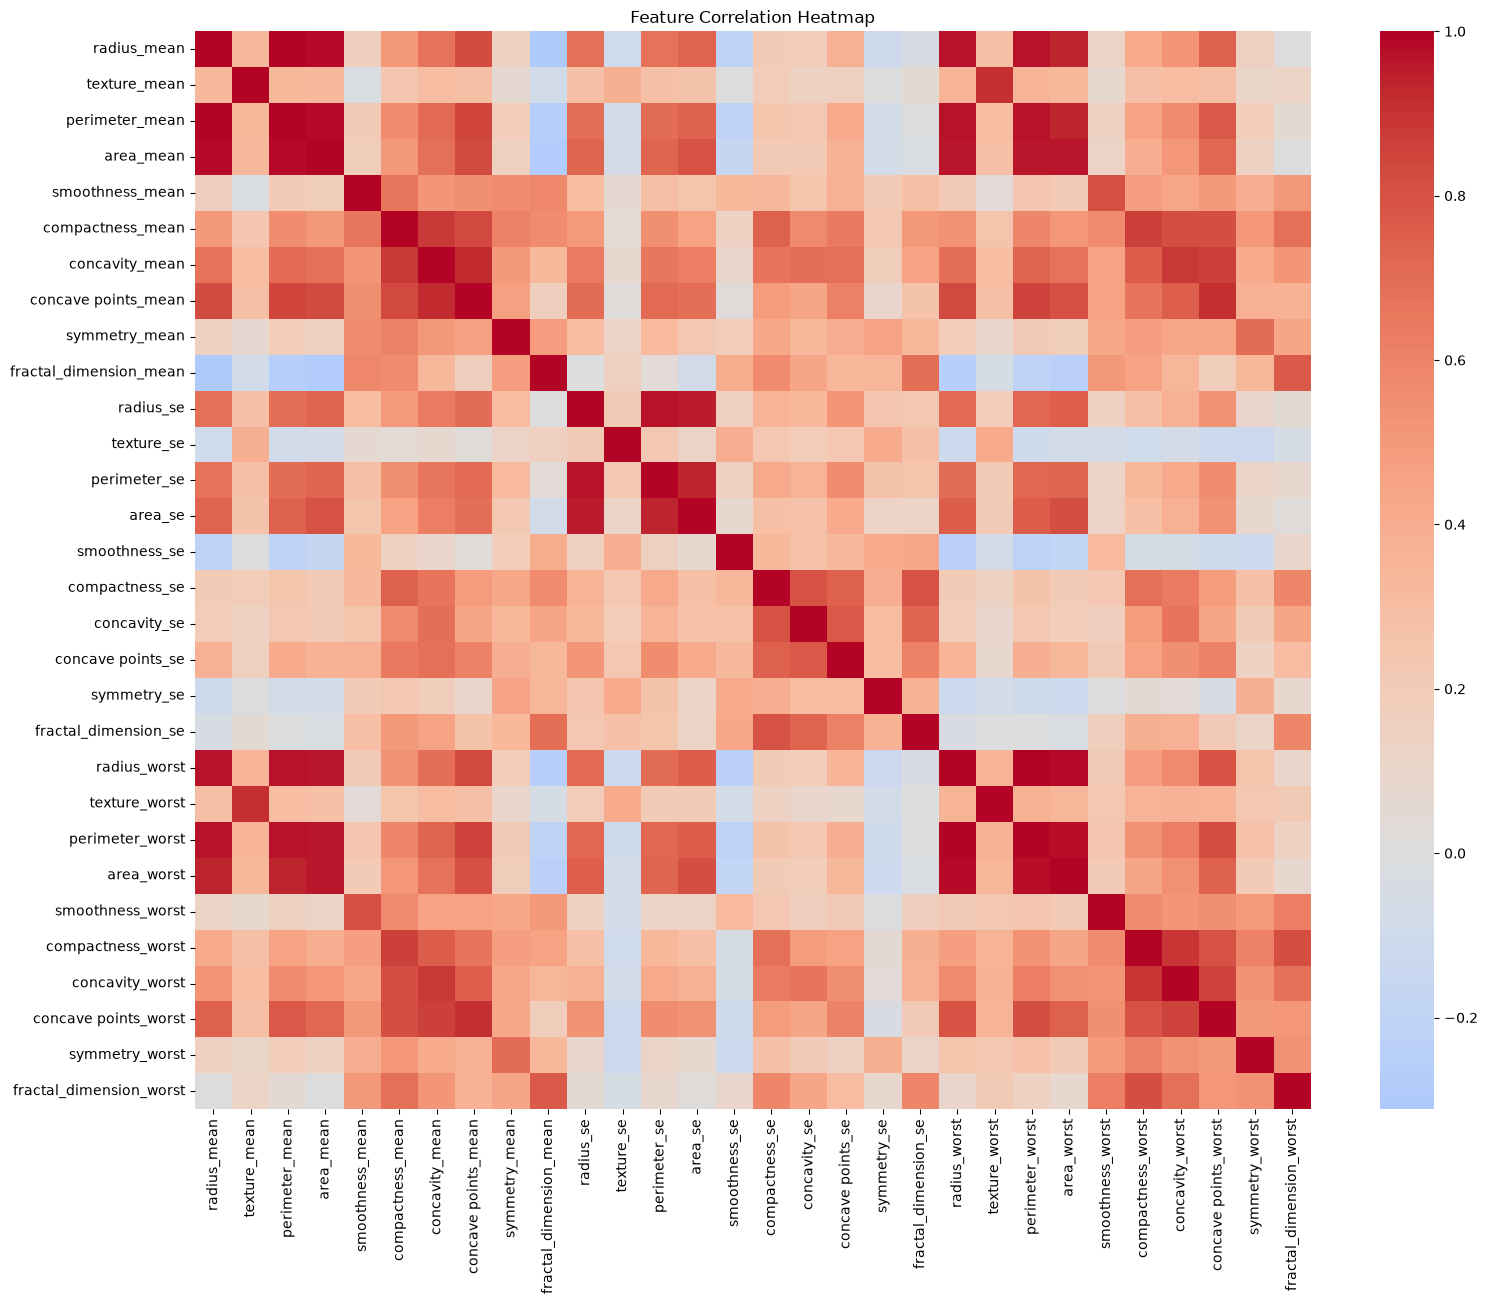

In [65]:
plt.figure(figsize=(18, 14))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Heatmap

Several features show strong positive correlations, especially measurements related to radius, perimeter, and area, indicating possible redundancy among features.

In [66]:
correlation_with_target = df.drop(columns=["diagnosis"]).corrwith(
    pd.Series(y_encoded, index=df.index)
)

top_features = correlation_with_target.abs().sort_values(
    ascending=False
).head(10)

print("Top 10 Features Related to Diagnosis:")
print(top_features)

Top 10 Features Related to Diagnosis:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
dtype: float64


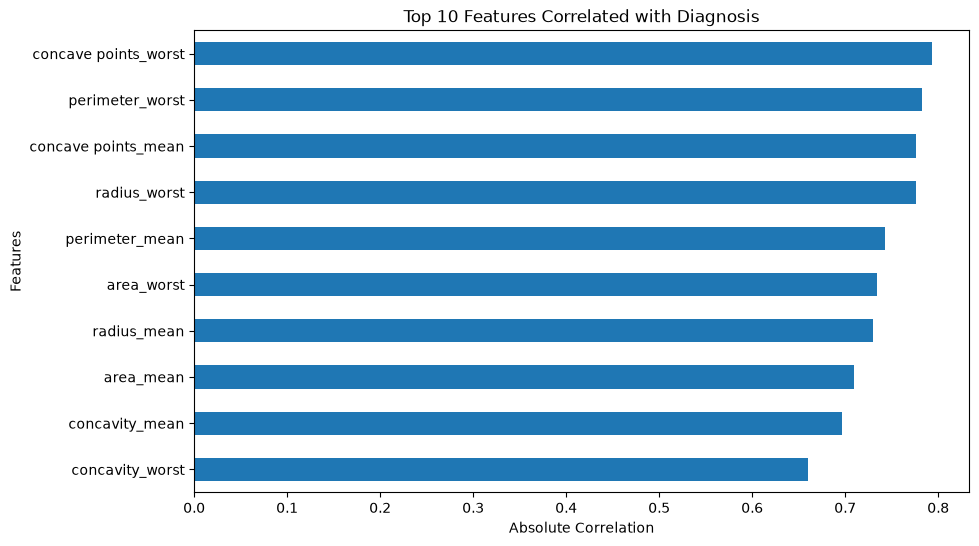

In [67]:
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with Diagnosis")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")

plt.show()

### Feature-Target Relationship

The strongest correlated features are useful candidates for visual analysis because they show greater association with the benign/malignant target.

In [68]:
selected_features = top_features.index[:4].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst']


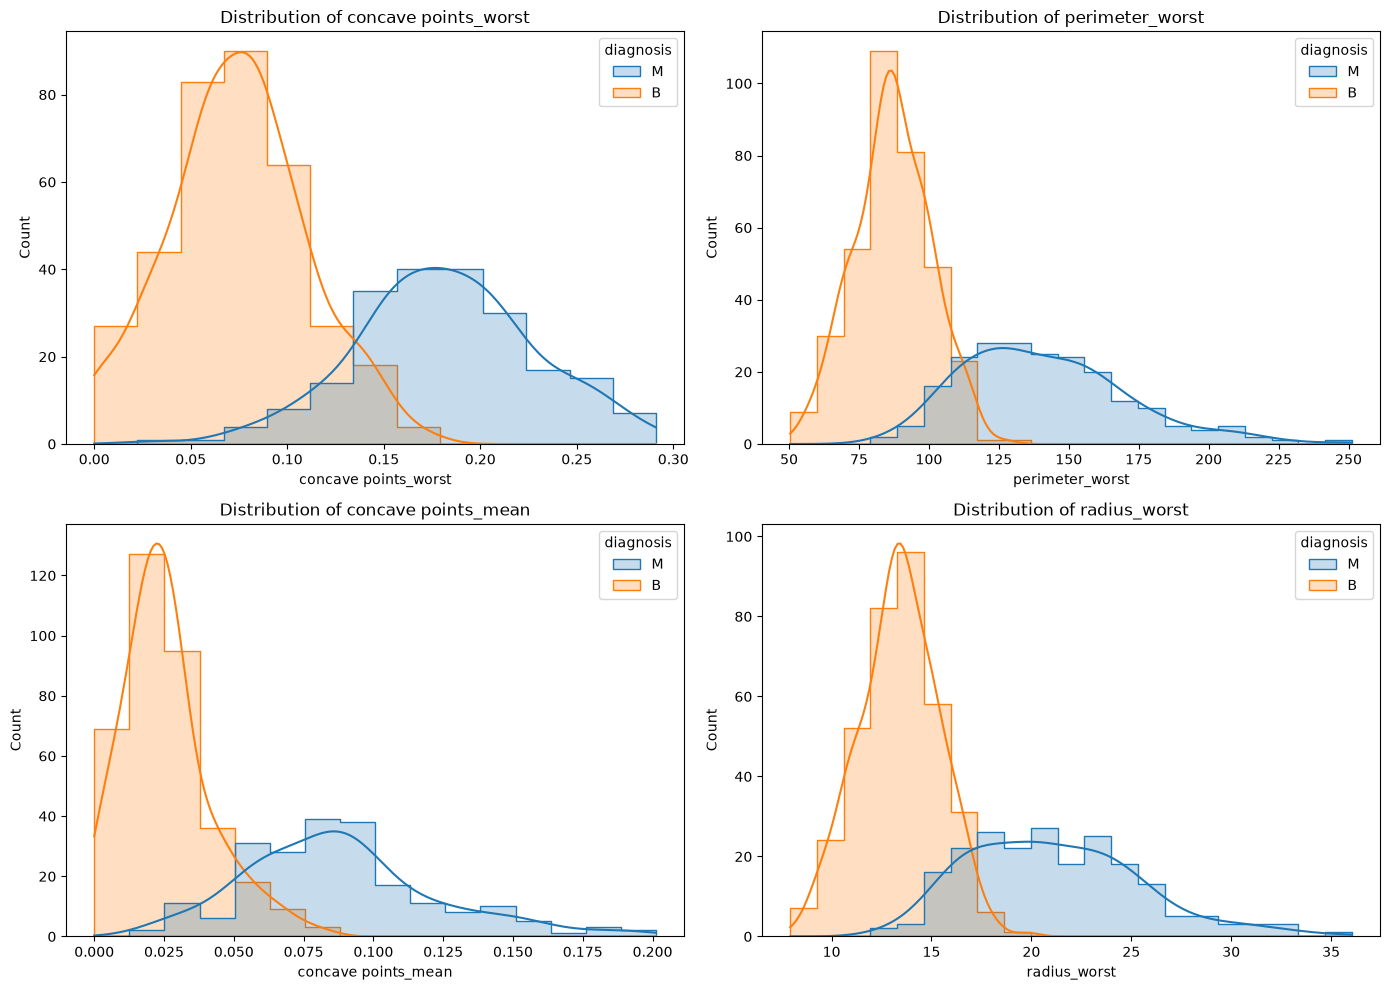

In [69]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, feature in zip(axes.flatten(), selected_features):

    sns.histplot(
        data=df,
        x=feature,
        hue="diagnosis",
        kde=True,
        element="step",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

### Feature Distributions

The distributions of several important features differ between benign and malignant samples, suggesting that these features contain useful classification information.

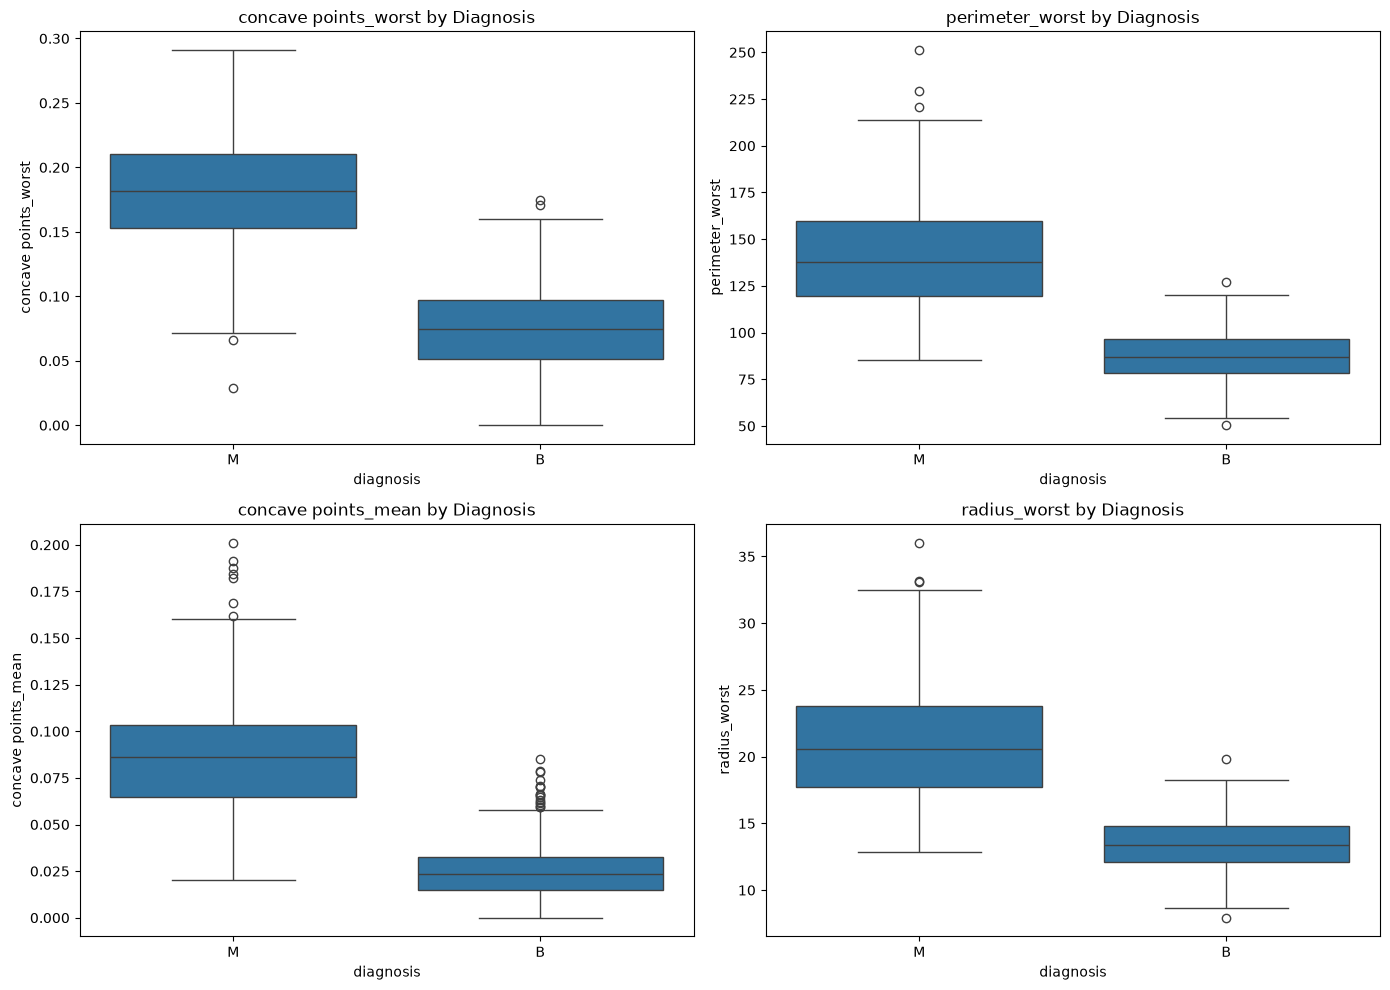

In [70]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, feature in zip(axes.flatten(), selected_features):

    sns.boxplot(
        data=df,
        x="diagnosis",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} by Diagnosis")

plt.tight_layout()
plt.show()

### Boxplot Comparison

The boxplots show differences in the central tendency and spread of important features between benign and malignant samples, supporting their predictive usefulness.

X-axis Feature: concave points_worst
Y-axis Feature: perimeter_worst


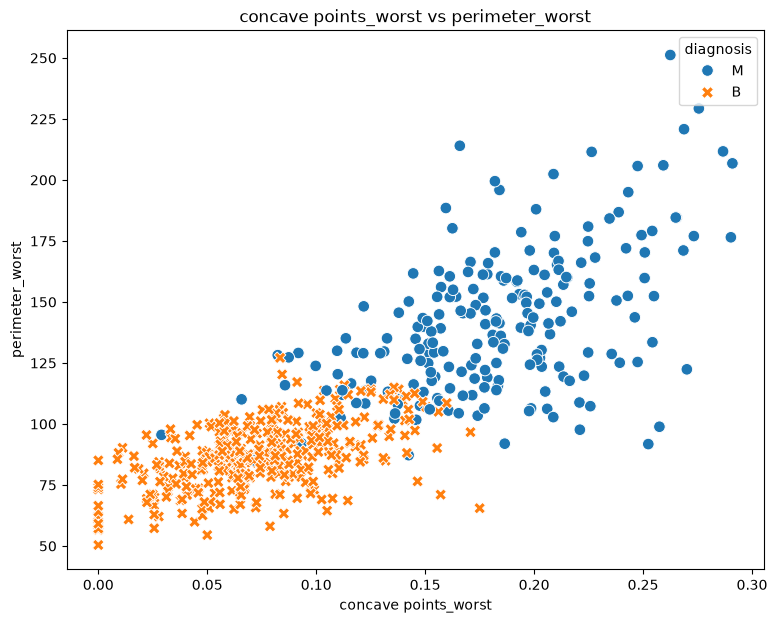

In [71]:
feature_x = top_features.index[0]
feature_y = top_features.index[1]

print("X-axis Feature:", feature_x)
print("Y-axis Feature:", feature_y)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x=feature_x,
    y=feature_y,
    hue="diagnosis",
    style="diagnosis",
    s=70
)

plt.title(f"{feature_x} vs {feature_y}")
plt.xlabel(feature_x)
plt.ylabel(feature_y)

plt.show()

### Feature Scatter Plot

The scatter plot shows partial separation between benign and malignant samples, although some overlap exists; using multiple features should improve classification.

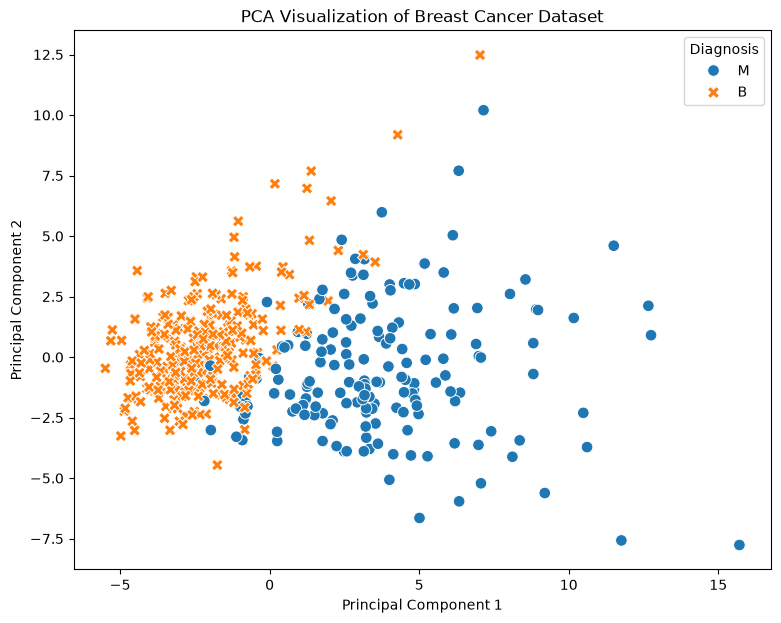

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Diagnosis"] = y_train

pca_df["Diagnosis"] = pca_df["Diagnosis"].map({
    0: "B",
    1: "M"
})

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    style="Diagnosis",
    s=70
)

plt.title("PCA Visualization of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [73]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.44593522 0.18545255]
Total Variance Explained: 0.631387776559559


### PCA Explained Variance

The first two principal components capture a portion of the total dataset variance, providing a compact 2D representation of the original feature space.